In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
data = pd.read_csv('facebook_ads.csv', encoding='latin1')

In [5]:
df = data.copy()

In [6]:
df.isnull().sum()

Names                 0
emails                0
Country               0
Time Spent on Site    0
Salary                0
Clicked               0
dtype: int64

In [7]:
df

,Names,emails,Country,Time Spent on Site,Salary,Clicked
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,25.649648,55330.06006,0
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,32.456107,79049.07674,1
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,20.945978,41098.60826,0
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,54.039325,37143.35536,1
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,34.249729,37355.11276,0
...,...,...,...,...,...,...
494,Rigel,egestas.blandit.Nam@semvitaealiquam.com,Sao Tome and Principe,19.222746,44969.13495,0
495,Walter,ligula@Cumsociis.ca,Nepal,22.665662,41686.20425,0
496,Vanna,Cum.sociis.natoque@Sedmolestie.edu,Zimbabwe,35.320239,23989.80864,0
497,Pearl,penatibus.et@massanonante.com,Philippines,26.539170,31708.57054,0


In [8]:
df = df.drop(['Names','emails','Country'],axis=1)

In [9]:
df

,Time Spent on Site,Salary,Clicked
0,25.649648,55330.06006,0
1,32.456107,79049.07674,1
2,20.945978,41098.60826,0
3,54.039325,37143.35536,1
4,34.249729,37355.11276,0
...,...,...,...
494,19.222746,44969.13495,0
495,22.665662,41686.20425,0
496,35.320239,23989.80864,0
497,26.539170,31708.57054,0


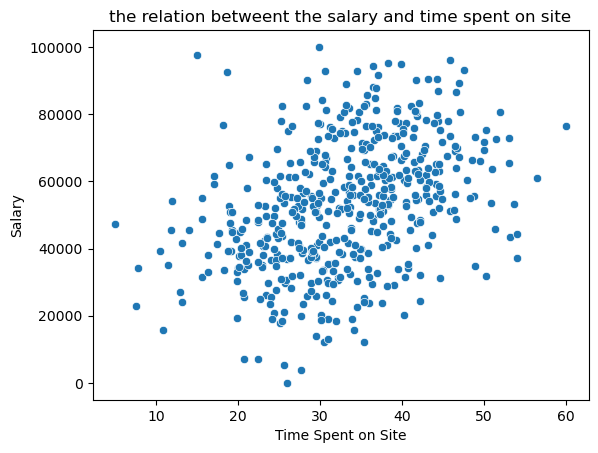

In [10]:
plt.Figure(figsize=(8,6))
sns.scatterplot(data =df,x='Time Spent on Site',y='Salary')
plt.title('the relation betweent the salary and time spent on site')
plt.show()

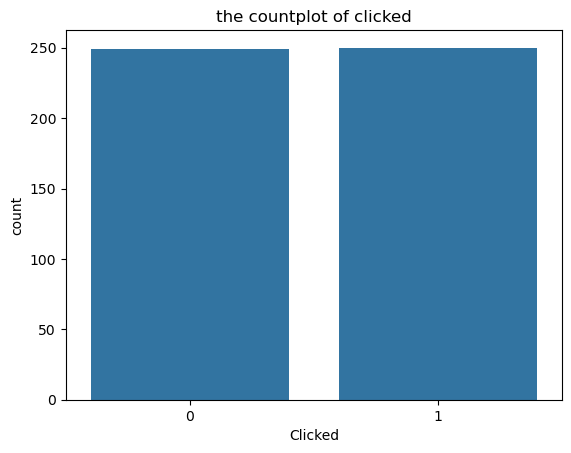

In [11]:
plt.Figure(figsize=(8,6))
sns.countplot(data =df,x ='Clicked')
plt.title('the countplot of clicked')
plt.show()

In [12]:
numeric_cols = df.select_dtypes(include=['number']).columns

numeric_cols = numeric_cols.drop('Clicked')



In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
df[numeric_cols]=scaler.fit_transform(df[numeric_cols])

In [16]:
df

,Time Spent on Site,Salary,Clicked
0,-0.799458,0.128258,0
1,-0.051029,1.378592,1
2,-1.316667,-0.621945,0
3,2.322233,-0.830444,1
4,0.146196,-0.819281,0
...,...,...,...
494,-1.506151,-0.417912,0
495,-1.127573,-0.590970,0
496,0.263907,-1.523825,0
497,-0.701647,-1.116935,0


In [18]:
x = df.drop(['Clicked'],axis=1)
y = df[['Clicked']]

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42,shuffle=True)

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
model = LogisticRegression()

In [23]:
model.fit(x_train,y_train)

c:\Users\seifa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



LogisticRegression()

In [24]:
y_pred = model.predict(x_test)

In [25]:
from sklearn.metrics import classification_report,f1_score,accuracy_score,confusion_matrix

In [26]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93        55
           1       0.97      0.84      0.90        45

    accuracy                           0.92       100
   macro avg       0.93      0.91      0.92       100
weighted avg       0.93      0.92      0.92       100



In [27]:
cm = confusion_matrix(y_pred,y_test)

<Axes: >

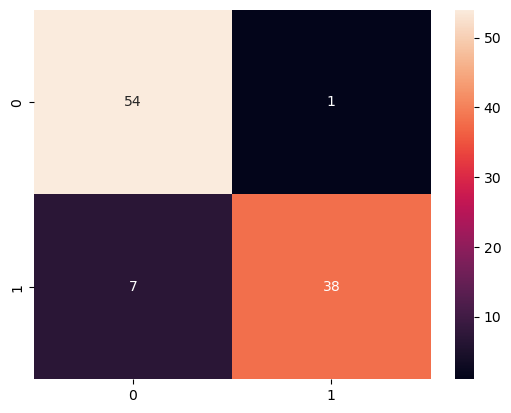

In [28]:
sns.heatmap(cm,annot= True)